In [14]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np

from sbi.inference import NPE,NLE

from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
from torch.distributions import Normal, Independent,InverseGamma

In [15]:
num_dim = 1  # Here, num_dim = 1, indicating we have one parameter σ^2


def simulator(theta, n=100):
    # theta[0] is σ^2
    mu, sigma2 = 0, theta[0]
    sigma = np.sqrt(sigma2)
    return mu + sigma * torch.randn(n)  # Generate n observations

prior = Independent(InverseGamma(torch.tensor([2.0]), torch.tensor([1.0])), 1)

In [16]:
prior, num_parameters, prior_returns_numpy = process_prior(prior)
simulator = process_simulator(simulator, prior, prior_returns_numpy)

check_sbi_inputs(simulator, prior)

In [17]:
inference = NLE(prior=prior)

# get test data
num_simulations = 500
theta = prior.sample((num_simulations,))
x = simulator(theta)

In [18]:
inference = inference.append_simulations(theta, x)
density_estimator = inference.train()

 Neural network successfully converged after 165 epochs.

In [19]:
posterior = inference.build_posterior(density_estimator)

/opt/anaconda3/envs/SBI_project/lib/python3.11/site-packages/sbi/inference/posteriors/mcmc_posterior.py:115: UserWarning: The default value for thinning in MCMC sampling has been changed from 10 to 1. This might cause the results differ from the last benchmark.
  thin = _process_thin_default(thin)


In [ ]:
# set true parameter
theta_true = torch.tensor([[0.8]])  # sigma^2 = 0.3
x_obs = simulator(theta_true)
samples = posterior.sample((1000,), x=x_obs)


Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

In [ ]:
import numpy as np

# Prior parameters
alpha_0 = 2
beta_0 = 1  # Prior variance

# Data preparation
Z = x_obs.numpy()  # Convert to NumPy array if it's a PyTorch tensor
Z_flat = Z.flatten()  # Flatten to a one-dimensional array

# Sample mean and sample size
Y_mean = np.mean(Z_flat)  # Sample mean
n = Z.size  # Sample size

# Compute total sample variance
variance = np.sum((Z_flat - Y_mean) ** 2) 

# Posterior mean μ'
alpha_poster = alpha_0 + n / 2
beta_poster = beta_0 + variance / 2 

# Output results
print("Posterior alpha:", alpha_poster)
print("Posterior beta:", beta_poster)


Posterior alpha: 52.0
Posterior beta: 53.16331100463867


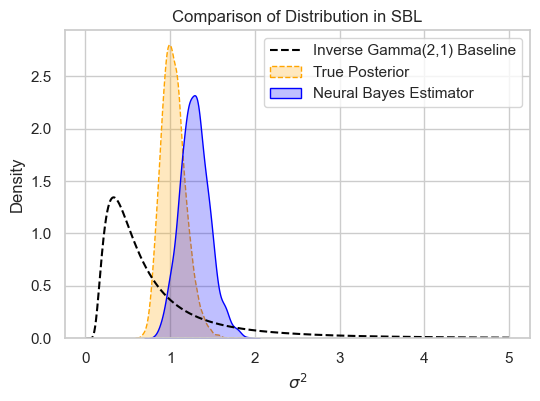

In [ ]:
# Assume alpha_poster and beta_poster are already defined
alpha_prior = 2.0  # Inverse Gamma shape parameter α
beta_prior = 1.0   # Inverse Gamma rate parameter β

# Sample from the Inverse Gamma distribution
# Inverse Gamma samples are generated by taking the reciprocal of Gamma samples
gamma_samples = np.random.gamma(shape=alpha_prior, scale=1 / beta_prior, size=10000)
inverse_gamma_samples = 1 / gamma_samples  # Convert to Inverse Gamma samples

# Create the plot
plt.figure(figsize=(6, 4))

# Generate density curve for Inverse Gamma(2,1)
x = np.linspace(0.01, 5, 1000)  # Inverse Gamma domain is x > 0 to avoid division by zero
y = stats.invgamma.pdf(x, a=2, scale=1)  # α=2, β=1

# Plot Inverse Gamma(2,1) as a baseline on the same graph
plt.plot(x, y, label="Inverse Gamma(2,1) Baseline", color="black", linestyle="--")

# Sample from the Posterior Inverse Gamma distribution
gamma_samples = np.random.gamma(shape=alpha_poster, scale=1 / beta_poster, size=10000)
inverse_gamma_samples = 1 / gamma_samples
sns.kdeplot(inverse_gamma_samples, label="True Posterior", fill=True, color="orange", linestyle="--")

# Extract the first dimension of samples (e.g., σ²)
sigma_samples = samples[:, 0].numpy()
sns.kdeplot(sigma_samples, label="Neural Bayes Estimator", fill=True, color="blue")

# Axis labels and legend
plt.xlabel(r"$\sigma^2$")
plt.ylabel("Density")
plt.title("Comparison of Distribution in SBL")
plt.legend()
plt.show()


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import pearsonr, linregress
from torch.distributions import InverseGamma

sigma2_prior = InverseGamma(torch.tensor(2.0), torch.tensor(1.0))

# ========== Simulate Data for Multiple Ground Truth ==========
num_samples = 50
theta_true_values = sigma2_prior.sample((num_samples,)).reshape(-1, 1)  # Sample values

posterior_means = []
posterior_stds = []

# Perform inference for each ground truth
for theta_true in theta_true_values:
    x_obs = simulator(theta_true.unsqueeze(0))  # Generate observations
    samples = posterior.sample((10000,), x=x_obs)
    mu_samples = samples[:, 0].numpy()
    posterior_means.append(np.mean(mu_samples))
    posterior_stds.append(np.std(mu_samples))

# Convert to NumPy arrays
ground_truth = theta_true_values.numpy().flatten()
estimated = np.array(posterior_means)
error_std = np.array(posterior_stds)

# ========== Recovery Line ==========
# Calculate R² and Pearson correlation coefficient
slope, intercept, r_value, p_value, std_err = linregress(ground_truth, estimated)
r_squared = r_value ** 2
pearson_corr, _ = pearsonr(ground_truth, estimated)


Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

...

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

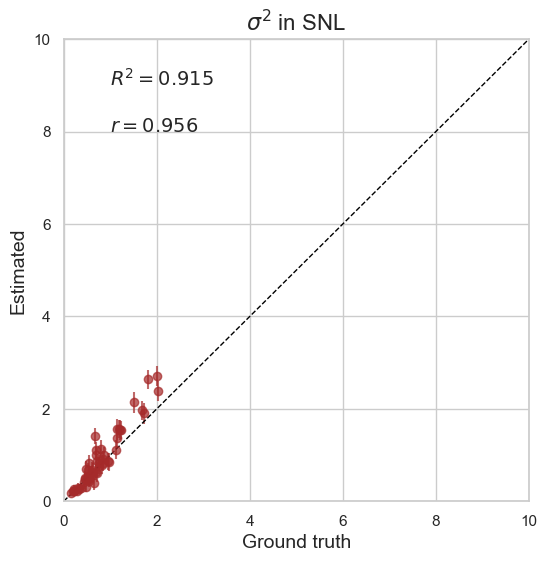

In [24]:
# ========== Recovery Line ==========
# Calculate R² and Pearson correlation coefficient
slope, intercept, r_value, p_value, std_err = linregress(ground_truth, estimated)
r_squared = r_value ** 2
pearson_corr, _ = pearsonr(ground_truth, estimated)

# ---------------- Recovery Line Plot ----------------
plt.figure(figsize=(6, 6))
sns.set(style="whitegrid")

plt.errorbar(ground_truth, estimated, yerr=error_std, fmt='o', color='brown', alpha=0.7)
plt.plot([0, 10], [0, 10], '--', color='black', linewidth=1)

# Annotate R² and r
plt.text(1, 9, rf"$R^2 = {r_squared:.3f}$", fontsize=14, fontstyle='italic')
plt.text(1, 8, rf"$r = {pearson_corr:.3f}$", fontsize=14, fontstyle='italic')

plt.xlabel("Ground truth", fontsize=14) 
plt.ylabel("Estimated", fontsize=14)   
plt.title(r"$\sigma^2$ in SNL", fontsize=16) 
plt.xlim(0, 10)
plt.ylim(0, 10) 
plt.show()


In [25]:
from scipy.interpolate import CubicSpline

def plot_rank_ecdf_final(
    estimated,
    ground_truth,
    difference=True,
    rank_ecdf_color="#a34f4f",
    fill_color="grey",
    figsize=(6, 6),
    title="Rank ECDF for μ",
    band_factor=1.68  
):

    ranks = np.sum(estimated[:, None] >= ground_truth, axis=1) / len(ground_truth)
    ranks = np.clip(ranks, 1e-8, 1 - 1e-8)

    # ---- ECDF Calculation ----
    ecdf_single = np.sort(ranks)
    x_values = np.linspace(0, 1, 100)
    yy = np.arange(1, len(ecdf_single) + 1) / len(ecdf_single)
    yy_interp = np.interp(x_values, ecdf_single, yy)

    cs = CubicSpline(x_values, yy_interp)
    x_smooth = np.linspace(0, 1, 300)
    yy_smooth = cs(x_smooth)

    # ---- ECDF Difference ----
    if difference:
        yy_smooth -= x_smooth
        ylabel = "ECDF difference"
    else:
        ylabel = "ECDF"

    # ---- Simultaneous ECDF Bands ----
    n = len(ranks)
    z = np.linspace(0, 1, 300)
    c = band_factor / np.sqrt(n)
    L = z - c * np.sqrt(z * (1 - z))
    H = z + c * np.sqrt(z * (1 - z))

    if difference:
        L -= z
        H -= z
        
    y_min = np.min(L)
    y_max = np.max(H)

    plt.figure(figsize=figsize)
    sns.set(style="whitegrid")

    plt.plot(x_smooth, yy_smooth, color=rank_ecdf_color, label="Rank ECDF", linewidth=2, antialiased=True)

    plt.fill_between(z, L, H, color=fill_color, alpha=0.35, label="95% Confidence Bands")

    plt.xlabel("Fractional rank statistic", fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=16)
    plt.xlim(0, 1)
    plt.ylim(y_min, y_max)  
    plt.legend(fontsize=10)
    plt.grid(True, linewidth=0.7, alpha=0.6)
    plt.show()


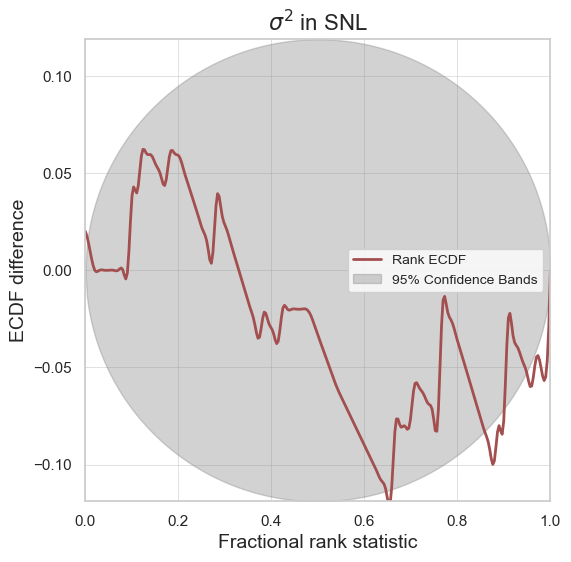

In [26]:
plot_rank_ecdf_final(estimated, ground_truth, difference=True, title=r"$\sigma^2$ in SNL")